In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
from IPython.display import display

ROOT = Path("../inference/clipseg_cloudsen12plus_prompt_variants").expanduser().resolve()

def get_agg_row(df: pd.DataFrame, csv_path: Path) -> pd.Series:
    if "id" not in df.columns:
        raise ValueError(f"'id' column missing in {csv_path}")
    agg = df[df["id"] == "__aggregate__"]
    if agg.empty:
        raise ValueError(f"No __aggregate__ row found in {csv_path}")
    return agg.iloc[0]

iou_csvs = sorted(ROOT.glob("V*_iou.csv"))
if not iou_csvs:
    raise FileNotFoundError(f"No V*_iou.csv files found in: {ROOT}")

rows = []
for p in iou_csvs:
    tag = p.stem.replace("_iou", "")
    df = pd.read_csv(p)
    agg = get_agg_row(df, p)

    out = {"variant": tag}

    iou_cols = [c for c in df.columns if c.startswith("iou_")]
    if "miou" in df.columns:
        out["miou"] = float(agg["miou"])
    elif iou_cols:
        out["miou"] = float(pd.to_numeric(agg[iou_cols], errors="coerce").mean())
    else:
        out["miou"] = np.nan

    for c in iou_cols:
        out[c] = float(pd.to_numeric(agg[c], errors="coerce"))

    rows.append(out)

variant_df = pd.DataFrame(rows)

variant_df["vnum"] = variant_df["variant"].str.extract(r"V(\d+)", expand=False).astype(int)
variant_df = variant_df.sort_values("vnum").drop(columns=["vnum"]).reset_index(drop=True)

display(variant_df)

,variant,miou,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
0,V1,0.222039,0.361088,0.308159,0.083555,0.135353
1,V2,0.196456,0.291248,0.345006,0.022516,0.127055
2,V3,0.165606,0.223484,0.289099,0.090741,0.059100
3,V4,0.164304,0.347268,0.138881,0.091394,0.079675
4,V5,0.187621,0.277354,0.293561,0.079286,0.100283
5,V6,0.165336,0.268412,0.254362,0.026659,0.111909
6,V7,0.067676,0.057729,0.068061,0.078974,0.065940
7,V8,0.216400,0.502066,0.168840,0.072285,0.122407
8,V9,0.165080,0.402239,0.102546,0.096379,0.059158
9,V10,0.107816,0.158710,0.144901,0.078622,0.049031


In [3]:
from pathlib import Path
import pandas as pd

ZS_MIOU_CSV = Path("../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv").expanduser().resolve()
print("ZS_MIOU_CSV:", ZS_MIOU_CSV, "exists:", ZS_MIOU_CSV.exists())

zs_df = pd.read_csv(ZS_MIOU_CSV)
zs_agg = get_agg_row(zs_df, ZS_MIOU_CSV)

zs_vals = {
    "miou": float(zs_agg["miou"]),
    "iou_clear": float(zs_agg["iou_clear"]),
    "iou_thick_cloud": float(zs_agg["iou_thick_cloud"]),
    "iou_thin_cloud": float(zs_agg["iou_thin_cloud"]),
    "iou_cloud_shadow": float(zs_agg["iou_cloud_shadow"]),
}

zs_vals

ZS_MIOU_CSV: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv exists: True


{'miou': 0.2550400406013244,
 'iou_clear': 0.520532380887666,
 'iou_thick_cloud': 0.277302215426787,
 'iou_thin_cloud': 0.0898395431914562,
 'iou_cloud_shadow': 0.1324860228993884}

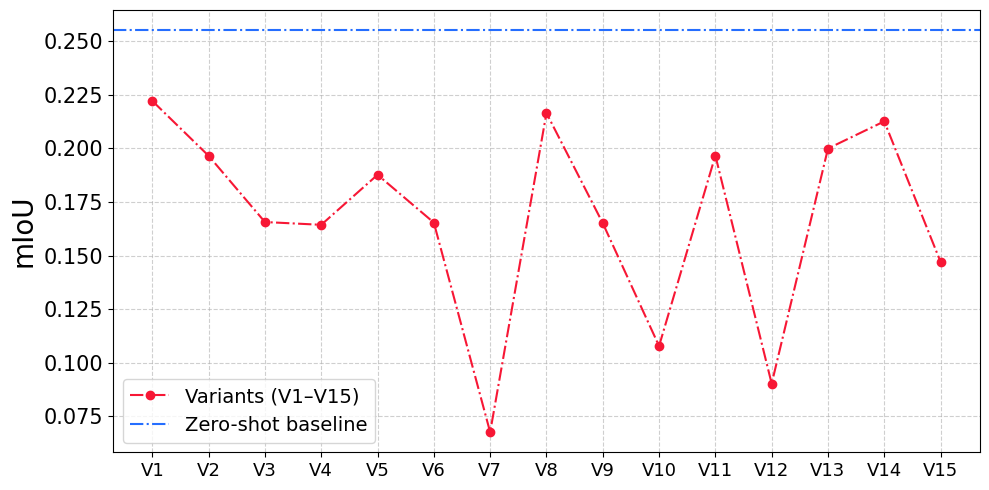

In [4]:
def plot_variants_vs_zs(metric: str, ylabel: str):
    x_labels = variant_df["variant"].tolist()
    y = variant_df[metric].astype(float).tolist()
    z = zs_vals[metric]

    plt.figure(figsize=(10, 5))

    plt.plot(
        range(len(x_labels)),
        y,
        marker="o",
        linestyle="-.",
        color="#f71735",
        label="Variants (V1–V15)"
    )

    plt.axhline(
        z,
        linestyle="-.",
        color="#256eff",
        label="Zero-shot baseline"
    )

    plt.xticks(range(len(x_labels)), x_labels, fontsize=13, rotation=0)
    plt.yticks(fontsize=15)
    plt.ylabel(ylabel, fontsize=20)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

plot_variants_vs_zs("miou", "mIoU")

In [22]:
CM_ZS_PATH = "../inference/clipseg_cloudsen12plus_zs/cm_clipseg_cloudsen12plus_zs_eval.csv"
CM_LORA_PATH = "../inference/clipseg_cloudsen12plus_lora/cm_clipseg_cloudsen12plus_lora_eval.csv"
CM_FT_PATH = "../inference/clipseg_cloudsen12plus_fft/cm_clipseg_cloudsen12plus_fft_eval.csv"

CLASS_NAMES = ["Clear", "Thick Cloud", "Thin Cloud", "Cloud Shadow"]
N_CLASSES = len(CLASS_NAMES)

In [23]:
cm_zs = pd.read_csv(CM_ZS_PATH)
cm_lora = pd.read_csv(CM_LORA_PATH)
cm_ft = pd.read_csv(CM_FT_PATH)

In [24]:
ids_zs = set(cm_zs["id"]) - {"__aggregate__"}
ids_l = set(cm_lora["id"]) - {"__aggregate__"}
ids_f = set(cm_ft["id"]) - {"__aggregate__"}

common_ids = sorted(list(ids_zs & ids_l & ids_f))

In [25]:
cm_zs_p = cm_zs[cm_zs["id"].isin(common_ids)].copy()
cm_lora_p = cm_lora[cm_lora["id"].isin(common_ids)].copy()
cm_ft_p = cm_ft[cm_ft["id"].isin(common_ids)].copy()

def confusion_from_row(row, n=N_CLASSES, prefix="cm_"):
    m = np.zeros((n, n), dtype=np.int64)
    for i in range(n):
        for j in range(n):
            col = f"{prefix}t{i}_p{j}"
            m[i, j] = int(row[col])
    return m

def aggregate_confusion(df, n=N_CLASSES):
    mats = []
    for _, r in df.iterrows():
        mats.append(confusion_from_row(r, n=n))
    return np.sum(mats, axis=0)

CM_ZS_GLOBAL = aggregate_confusion(cm_zs_p)
CM_LORA_GLOBAL = aggregate_confusion(cm_lora_p)
CM_FT_GLOBAL = aggregate_confusion(cm_ft_p)

In [26]:
CM_ZS_GLOBAL, CM_LORA_GLOBAL, CM_FT_GLOBAL

(array([[80135845,  7794025, 34259639, 14078306],
        [ 5013861, 23687361, 36511317,  7863275],
        [ 5771701,  2278202,  9081365,  4853800],
        [ 6896402,  2272701,  8328250,  6764350]]),
 array([[125430879,   4643588,   3119564,   3073784],
        [  3911143,  64660661,   1898798,   2605212],
        [  5977188,   4412933,  10686549,    908398],
        [  5524343,   4225570,    973499,  13538291]]),
 array([[126541578,   2652587,   3305435,   3768215],
        [  3553194,  64227166,   2340359,   2955095],
        [  4322447,   3082531,  13386653,   1193437],
        [  4023266,   2752081,    840542,  16645814]]))

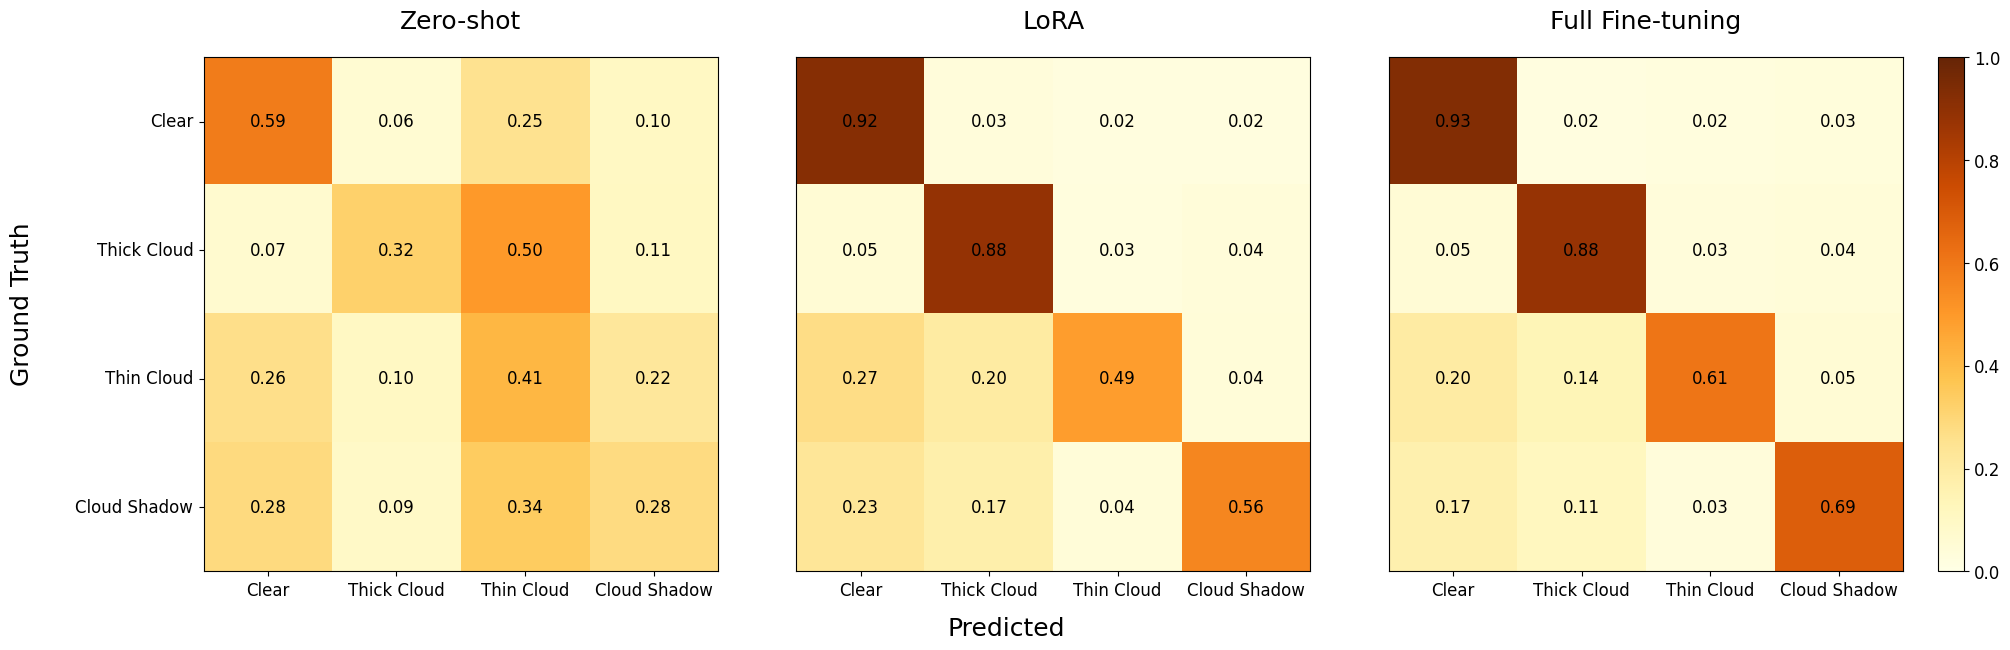

In [86]:
import numpy as np
import matplotlib.pyplot as plt

def _normalize_cm(cm, normalize="true"):
    cm = cm.astype(float)
    if normalize == "true":
        denom = cm.sum(axis=1, keepdims=True)
    elif normalize == "pred":
        denom = cm.sum(axis=0, keepdims=True)
    else:
        denom = 1.0
    return np.divide(cm, denom, out=np.zeros_like(cm, dtype=float), where=denom != 0)


def plot_confusions_grid(
    cms,
    titles,
    normalize="true",
    cmaps=None,
    figsize=(18, 5),
    vmin=0.0,
    vmax=1.0,
    annot=True,
    annot_fmt=".2f",
    annot_size=9,
    annot_colors=None,
    colorbar_label="",
    title_size=12,
    tick_size=9,
    xrot=0,
    yrot=90,
    show_single_colorbar=True,
    show_shared_axis_labels=True,
):
    n = len(cms)
    if cmaps is None:
        cmaps = ["Blues"] * n
    if annot_colors is None:
        annot_colors = ["black"] * n

    fig, axes = plt.subplots(1, n, figsize=figsize, constrained_layout=True, sharex=True, sharey=True)
    if n == 1:
        axes = [axes]

    last_im = None

    for idx, (ax, cm, title) in enumerate(zip(axes, cms, titles)):
        cmn = _normalize_cm(cm, normalize=normalize)

        last_im = ax.imshow(
            cmn,
            cmap=cmaps[idx],
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest"
        )

        ax.set_xticks(np.arange(N_CLASSES))
        ax.set_yticks(np.arange(N_CLASSES))


        ax.set_title(title, fontsize=title_size, y=1.04)

        ax.set_xticklabels(CLASS_NAMES, rotation=xrot, ha="center", fontsize=tick_size)
        ax.tick_params(axis="x", pad=4)

        if idx == 0:
            ax.set_yticklabels(CLASS_NAMES, rotation=yrot, ha="right", va="center", fontsize=tick_size)
            ax.tick_params(axis="y", pad=4)
        else:
            ax.tick_params(axis="y", left=False, labelleft=False)

        if not show_shared_axis_labels:
            ax.set_xlabel("Predicted", fontsize=tick_size + 1)
            if idx == 0:
                ax.set_ylabel("Actual", fontsize=tick_size + 1)

        if annot:
            for i in range(N_CLASSES):
                for j in range(N_CLASSES):
                    ax.text(
                        j, i, format(cmn[i, j], annot_fmt),
                        ha="center", va="center",
                        fontsize=annot_size,
                        color=annot_colors[idx]
                    )

    if show_shared_axis_labels:
        fig.supxlabel("Predicted", fontsize=tick_size + 6, y=-0.06)
        fig.supylabel("Ground Truth", fontsize=tick_size + 6)

    if show_single_colorbar and last_im is not None:
        cbar = fig.colorbar(last_im, ax=axes, location="right", fraction=0.025, pad=0.02)
        cbar.set_label(colorbar_label, fontsize=tick_size)
        cbar.ax.tick_params(labelsize=tick_size)

    plt.show()


plot_confusions_grid(
    cms=[CM_ZS_GLOBAL, CM_LORA_GLOBAL, CM_FT_GLOBAL],
    titles=["Zero-shot", "LoRA", "Full Fine-tuning"],
    normalize="true",
    cmaps=["YlOrBr", "YlOrBr", "YlOrBr"],
    figsize=(20, 6),
    vmin=0, vmax=1,
    annot=True,
    annot_size=12,
    annot_colors=["black", "black", "black"],
    title_size=18,
    tick_size=12,
    xrot=0,
    yrot=0,
    show_single_colorbar=True,
    show_shared_axis_labels=True,
)